In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("data/credit_card_fraud_2025.csv")
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Amount,Merchant_Category,Merchant_ID,Card_Type,Transaction_Type,Country,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Device_Type,Fraud_Flag
0,1,25795,2025-05-28 11:54:36,81.53,Online Services,8459,Gold,POS,Germany,1,1,0,1.61,11,Web,0
1,2,10860,2024-09-11 20:26:12,52.19,Fuel,8205,Debit,ATM,Germany,0,1,0,15.77,20,Web,0
2,3,86820,2024-11-02 12:39:23,27.70,Utilities,8076,Gold,Online,USA,0,1,0,9.19,12,Terminal,0
3,4,64886,2024-10-08 21:58:08,9.80,Clothing,3244,Gold,ATM,USA,0,1,0,9.42,21,Web,0
4,5,16265,2024-05-25 20:01:21,178.06,Electronics,3675,Gold,ATM,Germany,0,1,1,1.32,20,Web,0


In [8]:
# Convert Date:
df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"])

In [14]:
df["Fraud_Flag"].value_counts(normalize=True)


Fraud_Flag
0    0.985
1    0.015
Name: proportion, dtype: float64

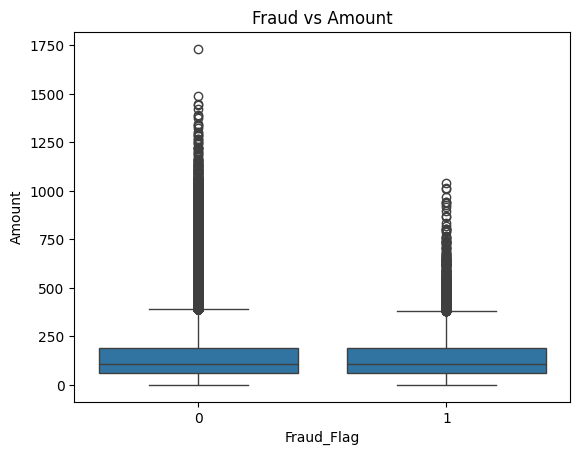

In [16]:
sns.boxplot(x="Fraud_Flag", y="Amount", data=df)
plt.title("Fraud vs Amount")
plt.show()

# Fraud (1) and NOT Fraud (0) - have similar distributions.
- Both have heavy right tail (Outliers)
- Similar Medians

### 🤔 Fraud transactions do not significantly differ in amount distributions, indicating fraud detection requires behavioural and contextual features rather than transaction size alone

In [19]:
pd.crosstab(df["Is_International"], df["Fraud_Flag"], normalize="index")

Fraud_Flag,0,1
Is_International,,
0,0.984973,0.015027
1,0.985154,0.014846


### International and Non-international fraud cases have similar fraud rates, common assumptions is that credit fraud usually usuallly exhibit higher fraud cases as harder to track culprit.

In [ ]:
cat_risk = df.groupby("Merchant_Category")["Fraud_Flag"].mean().sort_values(ascending=False)

Merchant_Category
Travel             0.015578
Online Services    0.015571
Groceries          0.015520
Entertainment      0.015198
Health             0.015151
Name: Fraud_Flag, dtype: float64

In [21]:
cat_risk

Merchant_Category
Travel             0.015578
Online Services    0.015571
Groceries          0.015520
Entertainment      0.015198
Health             0.015151
Utilities          0.014846
Fuel               0.014690
Electronics        0.014676
Food               0.014437
Clothing           0.014340
Name: Fraud_Flag, dtype: float64

### 🤔 All merchant categories have relatively uniform fraud risk - inidicating attackers exploit a wide range of transaction types rather than specific ones.

# Feature Engineering
## Transactional Risk 
   - High Amount (Compress Large Values - Using Log Transformation + Flag Largest Transactions (Unusually Large Purchases))
   - Night Time (Flag night transactions - Fraud often happens at night when user is asleep and less likely to notice activity)
   - Distance (Flag transactions far from user's usual location - fraud usually happen in different cities)
## Behavioural Risk
   - Customer Average (Calculate customer average spending)
   - Amount vs Average (Compare transactions to customer normal expenditure behaviour)
## Security Risk
   - No Chip/No Pin (Flag insecure transactions - can easily bypass security/ uses weak authentications)
   - Device Type


In [25]:
print(df["Transaction_Date"].dtype)

datetime64[us]


In [26]:
# Log transformation of amount - to reduce effect of very large outliers

df["Amount_log"] = np.log1p(df["Amount"])

In [27]:
df[["Amount", "Amount_log"]].head()

,Amount,Amount_log
0,81.53,4.413162
1,52.19,3.973870
2,27.70,3.356897
3,9.80,2.379546
4,178.06,5.187721


In [28]:
# High Amount Flag - Marks top 5% highest transactions:

q95_amount = df["Amount"].quantile(0.95)
df["High_Amount_Flag"] = (df["Amount"] >= q95_amount).astype(int)

In [29]:
df["High_Amount_Flag"].value_counts()

High_Amount_Flag
0    474999
1     25001
Name: count, dtype: int64

In [30]:
# Night Transaction Flag - Mark transactions between 12 AM to 5 AM.
df ["Is_Night"] = df["Hour_of_Day"].between(0,5).astype(int)

In [31]:
df[["Hour_of_Day", "Is_Night"]].head(10)

,Hour_of_Day,Is_Night
0,11,0
1,20,0
2,12,0
3,21,0
4,20,0
5,18,0
6,17,0
7,15,0
8,8,0
9,22,0


In [32]:
df["Is_Night"].value_counts()

Is_Night
0    375649
1    124351
Name: count, dtype: int64

In [33]:
# Weekend Flag - Mark Saturday and Sunday Transactions

df["Is_Weekend"] = (df["Transaction_Date"].dt.day_of_week >= 5).astype(int)

In [34]:
df[["Transaction_Date", "Is_Weekend"]].head()

,Transaction_Date,Is_Weekend
0,2025-05-28 11:54:36,0
1,2024-09-11 20:26:12,0
2,2024-11-02 12:39:23,1
3,2024-10-08 21:58:08,0
4,2024-05-25 20:01:21,1


In [35]:
df["Is_Weekend"].value_counts()

Is_Weekend
0    357353
1    142647
Name: count, dtype: int64

In [36]:
# Day Name
df["Day_Name"] = df["Transaction_Date"].dt.day_name()

In [37]:
df[["Transaction_Date", "Day_Name"]].head()

,Transaction_Date,Day_Name
0,2025-05-28 11:54:36,Wednesday
1,2024-09-11 20:26:12,Wednesday
2,2024-11-02 12:39:23,Saturday
3,2024-10-08 21:58:08,Tuesday
4,2024-05-25 20:01:21,Saturday


In [38]:
# Far from Home Tag - Marks Top 10% farthest transactions
q90_distance = df["Distance_From_Home"].quantile(0.90)
df["Far_From_Home"] = (df["Distance_From_Home"] > q90_distance).astype(int)

In [39]:
df["Far_From_Home"].value_counts()

Far_From_Home
0    450063
1     49937
Name: count, dtype: int64

In [40]:
df[["Distance_From_Home", "Far_From_Home"]].head()

,Distance_From_Home,Far_From_Home
0,1.61,0
1,15.77,1
2,9.19,0
3,9.42,0
4,1.32,0


In [42]:
#Customer Average Amount:

df["Customer_Avg_Amount"] = df.groupby("Customer_ID")["Amount"].transform("mean")

In [44]:
df[["Customer_ID", "Amount", "Customer_Avg_Amount"]].head(10)

,Customer_ID,Amount,Customer_Avg_Amount
0,25795,81.53,190.420000
1,10860,52.19,154.331667
2,86820,27.70,156.890000
3,64886,9.80,91.817143
4,16265,178.06,197.622500
5,92386,395.10,137.734000
6,47194,67.33,90.256000
7,97498,100.11,134.961250
8,54131,42.59,134.206000
9,70263,111.45,164.543333


In [45]:
# Amount compared to Customer Average:

df["Amount_vs_Avg"] = df["Amount"] / (df["Customer_Avg_Amount"] + 1e-6)

In [46]:
df[["Amount", "Customer_Avg_Amount", "Amount_vs_Avg"]].head(10)

,Amount,Customer_Avg_Amount,Amount_vs_Avg
0,81.53,190.420000,0.428159
1,52.19,154.331667,0.338168
2,27.70,156.890000,0.176557
3,9.80,91.817143,0.106734
4,178.06,197.622500,0.901011
5,395.10,137.734000,2.868573
6,67.33,90.256000,0.745989
7,100.11,134.961250,0.741768
8,42.59,134.206000,0.317348
9,111.45,164.543333,0.677329


In [47]:
df["Above_Customer_Avg"] = (df["Amount_vs_Avg"] > 2).astype(int)

In [48]:
df["Above_Customer_Avg"].value_counts()

Above_Customer_Avg
0    453245
1     46755
Name: count, dtype: int64

In [49]:
df[["Amount", "Customer_Avg_Amount", "Amount_vs_Avg", "Above_Customer_Avg"]].head(10)

,Amount,Customer_Avg_Amount,Amount_vs_Avg,Above_Customer_Avg
0,81.53,190.420000,0.428159,0
1,52.19,154.331667,0.338168,0
2,27.70,156.890000,0.176557,0
3,9.80,91.817143,0.106734,0
4,178.06,197.622500,0.901011,0
5,395.10,137.734000,2.868573,1
6,67.33,90.256000,0.745989,0
7,100.11,134.961250,0.741768,0
8,42.59,134.206000,0.317348,0
9,111.45,164.543333,0.677329,0


In [50]:
# Merchant Category Risk - Avg Fraud Rate by Merchant Category:

cat_risk = df.groupby("Merchant_Category")["Fraud_Flag"].mean().sort_values(ascending=False)
print(cat_risk)

Merchant_Category
Travel             0.015578
Online Services    0.015571
Groceries          0.015520
Entertainment      0.015198
Health             0.015151
Utilities          0.014846
Fuel               0.014690
Electronics        0.014676
Food               0.014437
Clothing           0.014340
Name: Fraud_Flag, dtype: float64


In [67]:
high_risk_cats = cat_risk[cat_risk > cat_risk.quantile(0.80)].index
df["High_Risk_Category"] = df["Merchant_Category"].isin(high_risk_cats).astype(int)

In [68]:
df["High_Risk_Category"].value_counts()

High_Risk_Category
0    400542
1     99458
Name: count, dtype: int64

In [70]:
df[["Merchant_Category", "High_Risk_Category"]]

,Merchant_Category,High_Risk_Category
0,Online Services,1
1,Fuel,0
2,Utilities,0
3,Clothing,0
4,Electronics,0
...,...,...
499995,Online Services,1
499996,Groceries,0
499997,Online Services,1
499998,Fuel,0


In [51]:
# No Chip and No Pin - Security Issues\

df["No_Chip_No_Pin"] = ((df["Is_Chip"] == 0) & (df["Is_Pin_Used"] == 0)).astype(int)

In [52]:
df["No_Chip_No_Pin"].value_counts()

No_Chip_No_Pin
1    280019
0    219981
Name: count, dtype: int64

In [53]:
df[["Is_Chip", "Is_Pin_Used", "No_Chip_No_Pin"]].head(10)

,Is_Chip,Is_Pin_Used,No_Chip_No_Pin
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,1,0
5,0,1,0
6,0,1,0
7,0,0,1
8,0,0,1
9,0,1,0


In [54]:
# High Distance & High Amount
df["High_Distance_And_Amount"] = ((df["Far_From_Home"] == 1) & (df["High_Amount_Flag"] == 1)).astype(int)

In [56]:
df["High_Distance_And_Amount"].value_counts()

High_Distance_And_Amount
0    497468
1      2532
Name: count, dtype: int64

In [57]:
df[["Far_From_Home", "High_Amount_Flag", "High_Distance_And_Amount"]].head(10)

,Far_From_Home,High_Amount_Flag,High_Distance_And_Amount
0,0,0,0
1,1,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,1,0
6,0,0,0
7,0,0,0
8,0,0,0
9,0,0,0


In [58]:
# Interntational & Far From Home:
df["International_And_Far"] = ((df["Is_International"] == 1) & (df["Far_From_Home"] == 1)).astype(int)

In [59]:
df["International_And_Far"].value_counts()

International_And_Far
0    492529
1      7471
Name: count, dtype: int64

In [60]:
df[["Is_International", "Far_From_Home", "International_And_Far"]].head(10)

,Is_International,Far_From_Home,International_And_Far
0,1,0,0
1,0,1,0
2,0,0,0
3,0,0,0
4,0,0,0
5,1,0,0
6,0,0,0
7,0,0,0
8,0,0,0
9,0,0,0


In [61]:
#Night and No Pin:
df["Night_No_Pin"] = ((df["Is_Night"] == 1) & (df["Is_Pin_Used"] == 0)).astype(int)

In [62]:
df["Night_No_Pin"].value_counts()

Night_No_Pin
0    400403
1     99597
Name: count, dtype: int64

In [63]:
df[["Is_Night", "Is_Pin_Used", "Night_No_Pin"]].head(10)

,Is_Night,Is_Pin_Used,Night_No_Pin
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,1,0
5,0,1,0
6,0,1,0
7,0,0,0
8,0,0,0
9,0,1,0


In [64]:
# Device Risk 
device_risk = df.groupby("Device_Type")["Fraud_Flag"].mean().sort_values(ascending=False)
print(device_risk)

Device_Type
Terminal    0.015330
Mobile      0.015242
Web         0.014424
Name: Fraud_Flag, dtype: float64


In [71]:
df["Device_Fraud_Rate"] = df["Device_Type"].map(device_risk)

In [72]:
df[["Device_Type", "Device_Fraud_Rate"]].head()

,Device_Type,Device_Fraud_Rate
0,Web,0.014424
1,Web,0.014424
2,Terminal,0.015330
3,Web,0.014424
4,Web,0.014424


In [65]:
txn_risk = df.groupby("Transaction_Type")["Fraud_Flag"].mean().sort_values(ascending=False)
print(txn_risk)

Transaction_Type
ATM       0.015028
POS       0.015004
Online    0.014968
Name: Fraud_Flag, dtype: float64


In [73]:
df["TxnType_Fraud_Rate"] = df["Transaction_Type"].map(txn_risk)

In [74]:
df[["Transaction_Type", "TxnType_Fraud_Rate"]].head()

,Transaction_Type,TxnType_Fraud_Rate
0,POS,0.015004
1,ATM,0.015028
2,Online,0.014968
3,ATM,0.015028
4,ATM,0.015028


In [79]:
df.head(1)

,Transaction_ID,Customer_ID,Transaction_Date,Amount,Merchant_Category,Merchant_ID,Card_Type,Transaction_Type,Country,Is_International,...,Customer_Avg_Amount,Amount_vs_Avg,Above_Customer_Avg,No_Chip_No_Pin,High_Distance_And_Amount,International_And_Far,Night_No_Pin,High_Risk_Category,Device_Fraud_Rate,TxnType_Fraud_Rate
0,1,25795,2025-05-28 11:54:36,81.53,Online Services,8459,Gold,POS,Germany,1,...,190.42,0.428159,0,0,0,0,0,1,0.014424,0.015004


In [81]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Amount',
       'Merchant_Category', 'Merchant_ID', 'Card_Type', 'Transaction_Type',
       'Country', 'Is_International', 'Is_Chip', 'Is_Pin_Used',
       'Distance_From_Home', 'Hour_of_Day', 'Device_Type', 'Fraud_Flag',
       'Amount_log', 'High_Amount_Flag', 'Is_Night', 'Is_Weekend', 'Day_Name',
       'Far_From_Home', 'Customer_Avg_Amount', 'Amount_vs_Avg',
       'Above_Customer_Avg', 'No_Chip_No_Pin', 'High_Distance_And_Amount',
       'International_And_Far', 'Night_No_Pin', 'High_Risk_Category',
       'Device_Fraud_Rate', 'TxnType_Fraud_Rate'],
      dtype='str')

In [ ]:
# df.to_csv("data/fraud_feature_engineered.csv", index=False)